In [1]:
import pandas as pd
import torch
import numpy as np
from carla.recourse_methods import GrowingSpheres, Clue, Dice, Face
from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier
from data import (
    load_l_dataset,
    load_ring_dataset,
    load_bubbles,
    load_bubbles_noisy,
    load_one_moon,
    load_two_moon,
    load_infinity_dataset,
)
from property_procedures import (
    validity_loss_function,
    connected_loss_function,
    robust_loss_function,
    feasable_loss_function,
    discriminative_loss_function,
    plausable_loss_function,
    similarity_loss_function,
    counter_factual_optimization_routine,
combined_loss_function
)
import matplotlib.pyplot as plt
import matplotlib as mpl
from property_procedures.utils import (
    ensemble_probs,
    epistemic_uncertainty_ensemble,
    aleatoric_uncertainty_ensemble,
    total_uncertainty_ensemble,
    sample_delta_ball,
)
from synthetic_to_carla import Synthetic_CARLA, MyOwnModel


[INFO] Using Python-MIP package version 1.12.0 [model.py <module>]


/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DESIRED_VALIDITY = 0.999
DELTA = 0.2
OPTIMIZER_LR = 0.1
PROB_WEIGHT = 1
LAMBDA_1 = 1
LAMBDA_2 = 1
MAX_STEPS = 5000
PATIENCE = 50
DESIRED_CLASS = 1
ENSEMBLE_MEMBER_COUNT = 20
N_POINTS = 50
base_ensemble = [
    MLP_Classifier(
        input_shape=2,
        n_classes=2,
        n_layers=2,
        num_neurons=64,
        dropout_prob=0,
        batch_norm=False,
    )
    for _ in range(ENSEMBLE_MEMBER_COUNT)
]


In [3]:
DATASET_LOADERS = [
    (
        "bubbles",
        load_bubbles,
        {"n_samples": 1000},
        torch.tensor(
            np.array([3.9, 3.9]).reshape(-1, 2), dtype=torch.float, requires_grad=True
        ),
    ),
    (
        "l_dataset",
        load_l_dataset,
        {"n_samples": 333},
        torch.tensor(
            np.array([0, 10]).reshape(-1, 2), dtype=torch.float, requires_grad=True
        ),
    ),
    (
        "one_moon",
        load_one_moon,
        {"n_samples": 1000},
        torch.tensor(
            np.array([-1, 0]).reshape(-1, 2), dtype=torch.float, requires_grad=True
        ),
    ),
    (
        "ring_dataset",
        load_ring_dataset,
        {"n_samples": 1000, "inner_radius": 1.0, "outer_radius": 2.0, "noise": 0.1},
        torch.tensor(
            np.array([-1, -2]).reshape(-1, 2), dtype=torch.float, requires_grad=True
        ),
    ),
    (
        "bubbles_noisy",
        load_bubbles_noisy,
        {"n_samples": 1000},
        torch.tensor(
            np.array([2.5, 2.5]).reshape(-1, 2), dtype=torch.float, requires_grad=True
        ),
    ),
    (
        "two_moon",
        load_two_moon,
        {"n_samples": 1000},
        torch.tensor(
            np.array([0, 1]).reshape(-1, 2), dtype=torch.float, requires_grad=True
        ),
    ),
    (
        "infinity_dataset",
        load_infinity_dataset,
        {"n_samples": 1000},
        torch.tensor(
            np.array([2, 0]).reshape(-1, 2), dtype=torch.float, requires_grad=True
        ),
    ),
]
PROPERTY_LOADERS = [
    (
        "robust",
        robust_loss_function,
    ),
    (
        "feasability",
        feasable_loss_function,
    ),
    (
        "similarity",
        similarity_loss_function,
    ),
]

In [4]:
(dataset_name, loader, kwargs, point_of_interest) = DATASET_LOADERS[0]

In [5]:
points, y_labels, y_probs = loader(**kwargs)

# Train the ensemble model
ensemble_model = Ensemble_Classifier(base_ensemble, n_models=ENSEMBLE_MEMBER_COUNT)
ensemble_model.load(f"../models/Ensemble_{dataset_name.capitalize()}_50/")

In [30]:
cfs = []
cf_steps = []
for j, (property_name, property_function) in enumerate(PROPERTY_LOADERS):
        print(f"Evaluating property: {property_name} on dataset: {dataset_name}")

        # Run the property procedure
        counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_model,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=property_function,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
            optimization_method="adam"
        )
        cfs.append(counter_factual)
        cf_steps.append(counter_factual_steps)

cf_robust, cf_feasable, cf_similarity = cfs
cf_robust_steps, cf_feasable_steps, cf_similarity_steps = cf_steps

Evaluating property: robust on dataset: l_dataset


KeyboardInterrupt: 

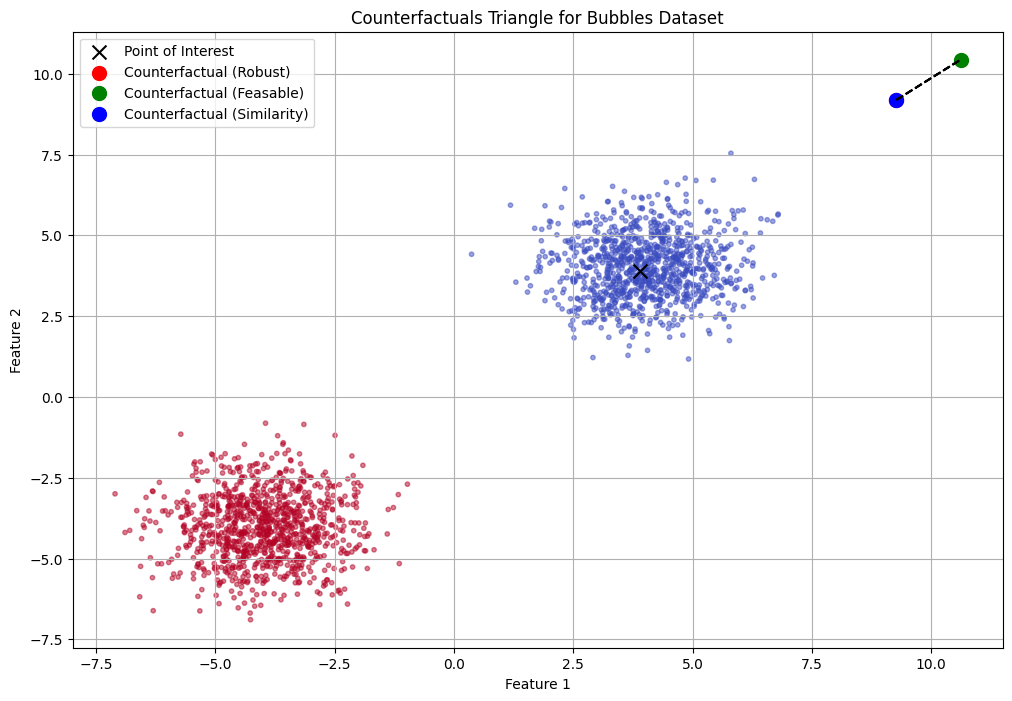

In [7]:
# Draw triangle connecting the three counterfactuals
def draw_triangle(cf_robust, cf_feasable, cf_similarity, points, y_labels, point_of_interest, dataset_name):
    plt.scatter(points[:, 0], points[:, 1], c=y_labels, cmap="coolwarm", alpha=0.5, s=10)
    plt.scatter(
        point_of_interest[0, 0].item(),
        point_of_interest[0, 1].item(),
        c="black",
        marker="x",
        s=100,
        label="Point of Interest",
    )
    plt.scatter(
        cf_robust[0, 0].item(),
        cf_robust[0, 1].item(),
        c="red",
        marker="o",
        s=100,
        label="Counterfactual (Robust)",
    )
    plt.scatter(
        cf_feasable[0, 0].item(),
        cf_feasable[0, 1].item(),
        c="green",
        marker="o",
        s=100,
        label="Counterfactual (Feasable)",
    )
    plt.scatter(
        cf_similarity[0, 0].item(),
        cf_similarity[0, 1].item(),
        c="blue",
        marker="o",
        s=100,
        label="Counterfactual (Similarity)",
    )
    # Draw triangle
    plt.plot(
        [cf_robust[0, 0].item(), cf_feasable[0, 0].item(), cf_similarity[0, 0].item(), cf_robust[0, 0].item()],
        [cf_robust[0, 1].item(), cf_feasable[0, 1].item(), cf_similarity[0, 1].item(), cf_robust[0, 1].item()],
        color="black",
        linestyle="--",
    )
    plt.title(f"Counterfactuals Triangle for {dataset_name.capitalize()} Dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
plt.figure(figsize=(12, 8))
draw_triangle(cf_robust, cf_feasable, cf_similarity, points, y_labels, point_of_interest, dataset_name)
plt.show()

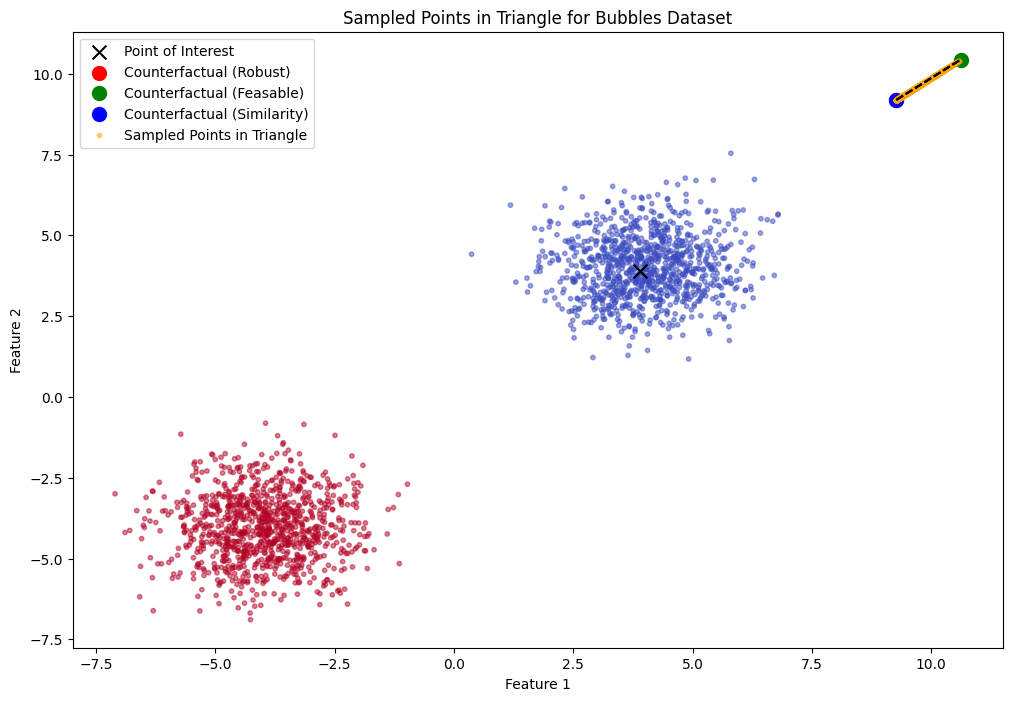

In [8]:
# Sample points in the triangle
def sample_points_in_triangle(p1, p2, p3, n_samples=100):
    points = []
    for _ in range(n_samples):
        r1 = np.random.rand()
        r2 = np.random.rand()
        if r1 + r2 > 1:
            r1 = 1 - r1
            r2 = 1 - r2
        point = (1 - r1 - r2) * p1 + r1 * p2 + r2 * p3
        points.append(point)
    return np.array(points)
# Sample points in the triangle formed by the counterfactuals
triangle_points = sample_points_in_triangle(
    cf_robust[0].detach().numpy(),
    cf_feasable[0].detach().numpy(),
    cf_similarity[0].detach().numpy(),
    n_samples=1000
)
# Plot the sampled points
plt.figure(figsize=(12, 8))
def draw_triangle_sampled(cf_robust, cf_feasable, cf_similarity, points, y_labels, point_of_interest, triangle_points, dataset_name):
    draw_triangle(cf_robust, cf_feasable, cf_similarity, points, y_labels, point_of_interest, dataset_name)
    # Draw triangle
    plt.scatter(
        triangle_points[:, 0],
        triangle_points[:, 1],
        c="orange",
        alpha=0.5,
        s=10,
        label="Sampled Points in Triangle",
    )
    plt.title(f"Sampled Points in Triangle for {dataset_name.capitalize()} Dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
draw_triangle_sampled(cf_robust, cf_feasable, cf_similarity, points, y_labels, point_of_interest, triangle_points, dataset_name)
plt.show()

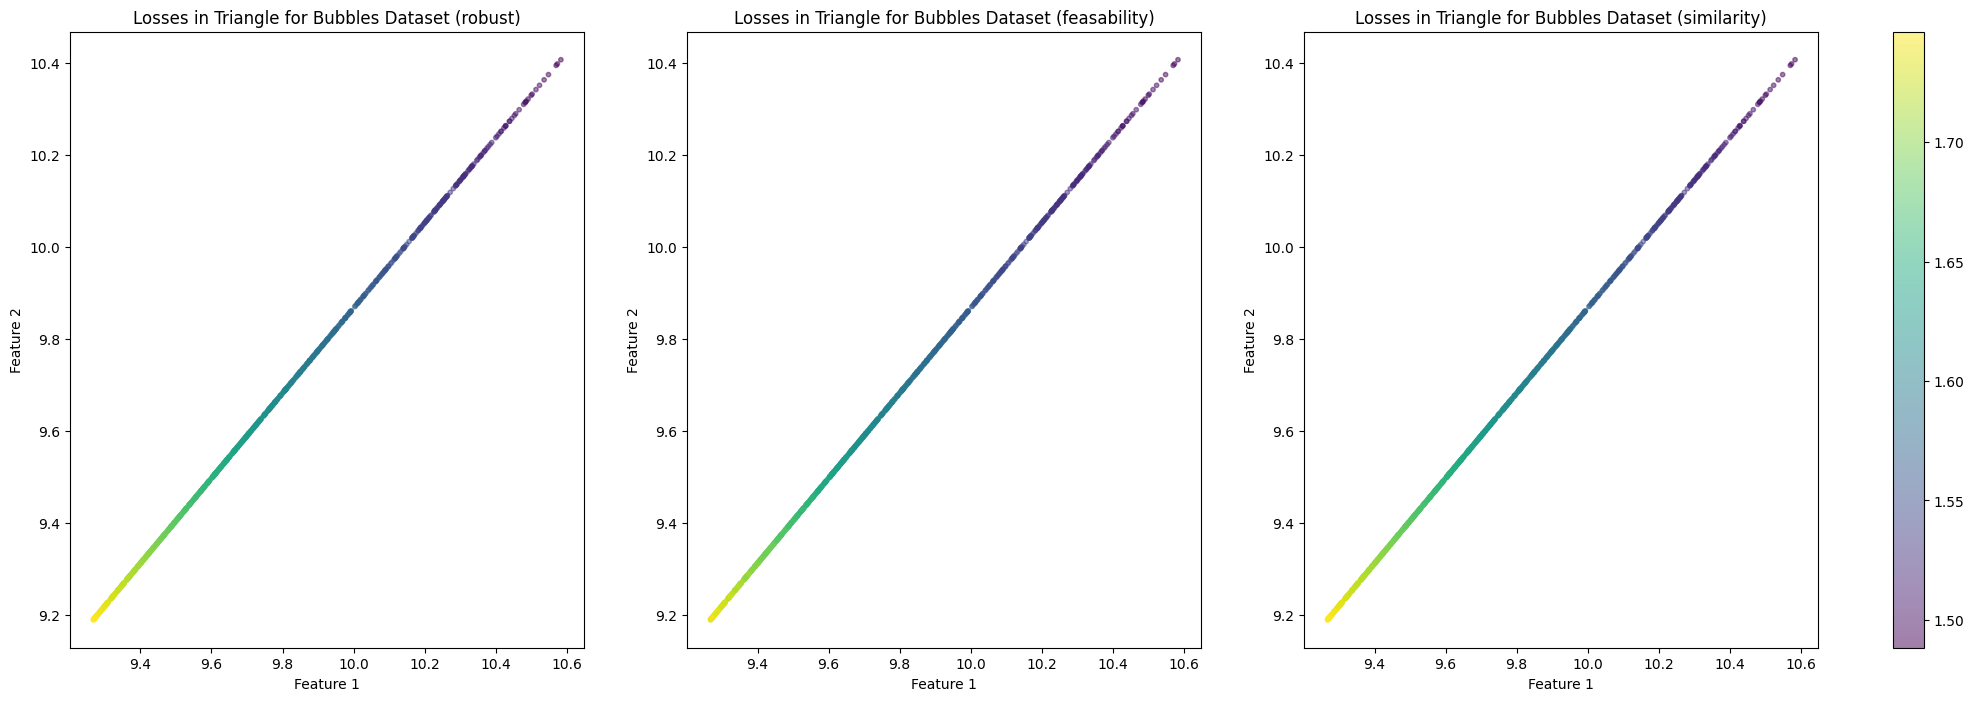

In [9]:
# Calculate the losses for the sampled points
def calculate_losses(points, model, property_function):
    losses = []
    for point in points:
        point_tensor = torch.tensor(point, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        loss,_ = property_function(None,
            point_tensor,
            model,
            ensemble_probs,
            aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_ensemble,
            DESIRED_CLASS,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            delta=DELTA,
            n_points=N_POINTS,
            start_cf_construction=False,)
        losses.append(loss.item())
    return np.array(losses)
# Calculate losses for the sampled points in the triangle
fig, axes = plt.subplots(ncols=3,figsize=(24, 8))
plots = []
for i, (property_name, property_function) in enumerate(PROPERTY_LOADERS):
    losses = calculate_losses(triangle_points, ensemble_model, property_function)
    plot = axes[i].scatter(
        triangle_points[:, 0],
        triangle_points[:, 1],
        c=losses,
        cmap="viridis",
        alpha=0.5,
        s=10,
    )
    plots.append(plot)
    axes[i].set_title(f"Losses in Triangle for {dataset_name.capitalize()} Dataset ({property_name})")
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")
fig.colorbar(plots[0], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
plt.show()

# L-Dataset

In [10]:
(dataset_name, loader, kwargs, point_of_interest) = DATASET_LOADERS[1]

points, y_labels, y_probs = loader(**kwargs)

ensemble_model = Ensemble_Classifier(base_ensemble, n_models=ENSEMBLE_MEMBER_COUNT)
ensemble_model.load(f"../models/Ensemble_{dataset_name.capitalize()}_50/")

In [11]:
cfs = []
cf_steps = []
for j, (property_name, property_function) in enumerate(PROPERTY_LOADERS):
        print(f"Evaluating property: {property_name} on dataset: {dataset_name}")

        # Run the property procedure
        counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_model,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=property_function,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
        )
        cfs.append(counter_factual)
        cf_steps.append(counter_factual_steps)

cf_robust, cf_feasable, cf_similarity = cfs
cf_robust_steps, cf_feasable_steps, cf_similarity_steps = cf_steps

Evaluating property: robust on dataset: l_dataset
Patience limit reached.
Evaluating property: feasability on dataset: l_dataset
Patience limit reached.
Evaluating property: similarity on dataset: l_dataset
Patience limit reached.


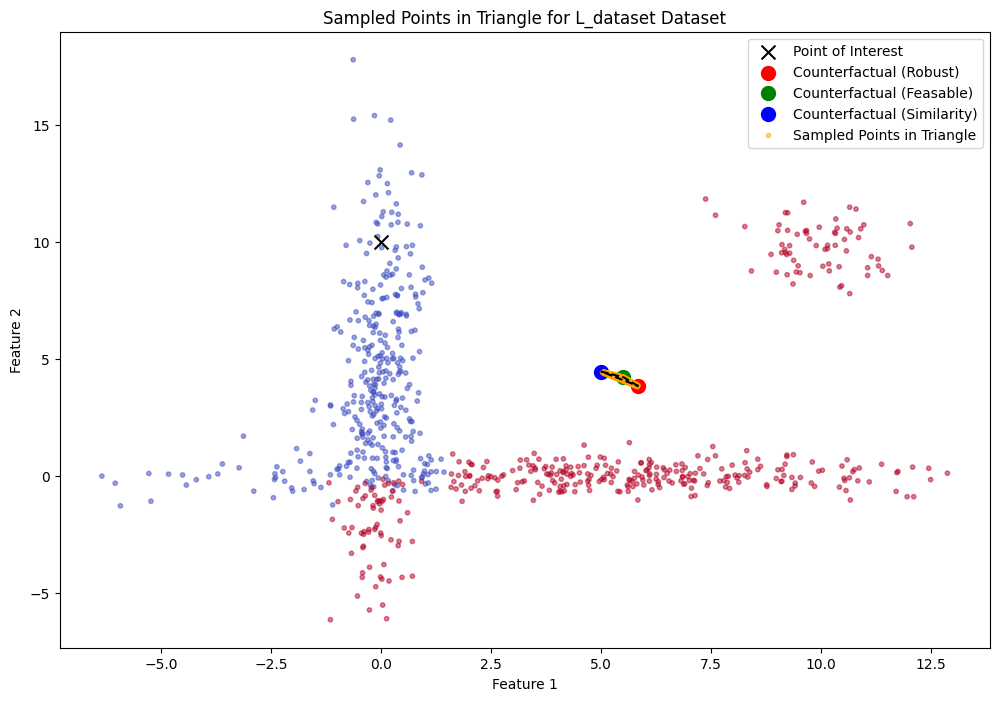

In [12]:
triangle_points = sample_points_in_triangle(
    cf_robust[0].detach().numpy(),
    cf_feasable[0].detach().numpy(),
    cf_similarity[0].detach().numpy(),
    n_samples=1000
)
# Plot the sampled points
plt.figure(figsize=(12, 8))
draw_triangle_sampled(cf_robust, cf_feasable, cf_similarity, points, y_labels, point_of_interest, triangle_points, dataset_name)
plt.show()

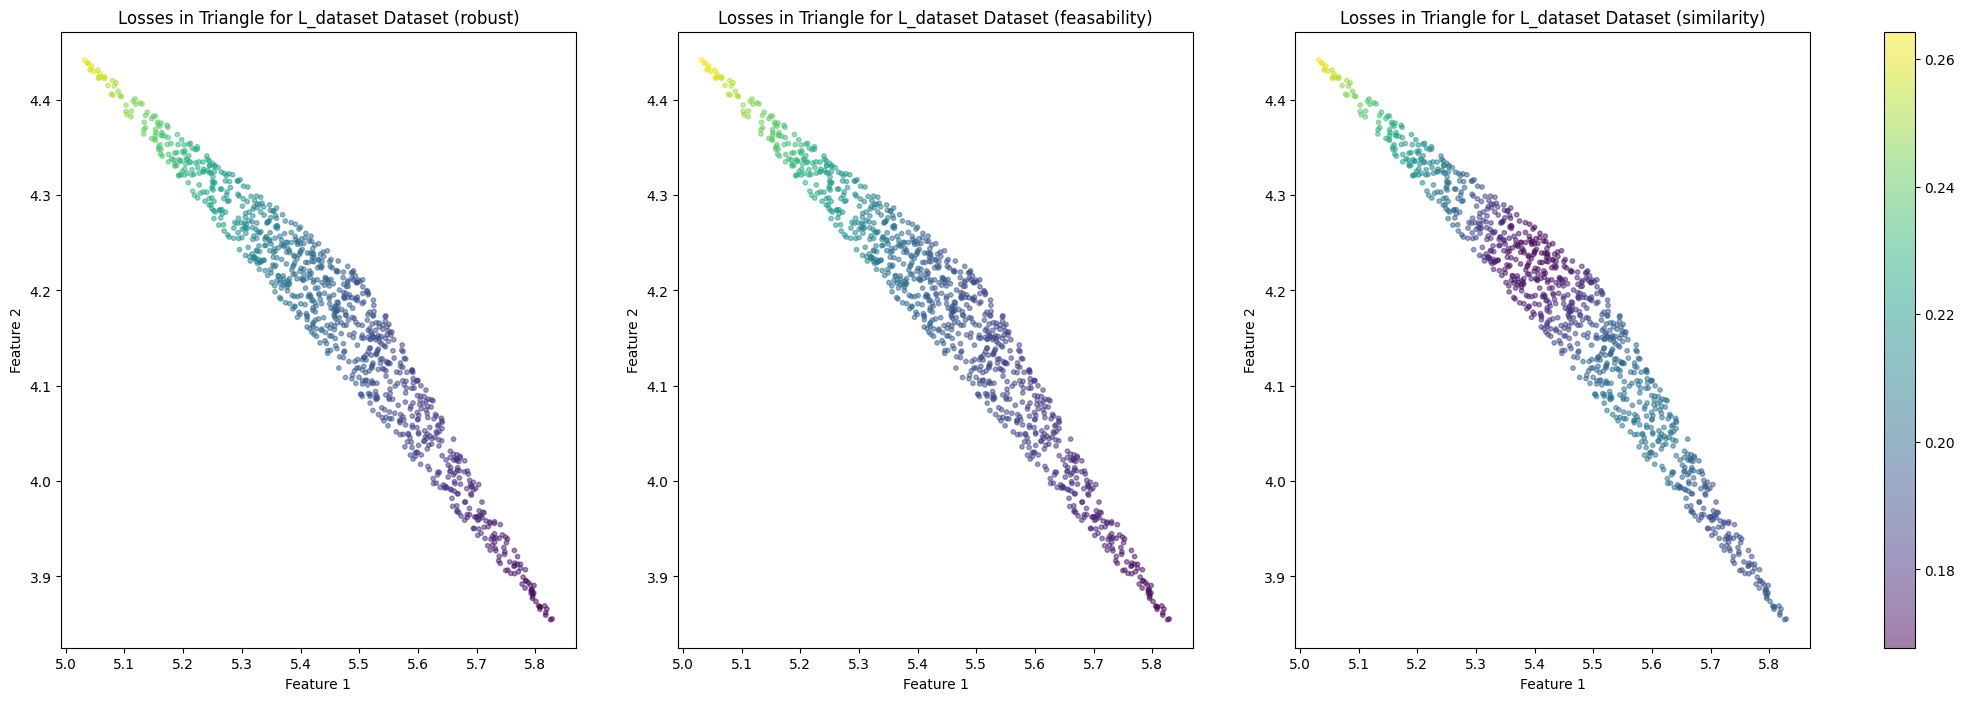

In [13]:
# Calculate the losses for the sampled points
def calculate_losses(points, model, property_function):
    losses = []
    for point in points:
        point_tensor = torch.tensor(point, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        loss,_ = property_function(None,
            point_tensor,
            model,
            ensemble_probs,
            aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_ensemble,
            DESIRED_CLASS,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            delta=DELTA,
            n_points=N_POINTS,
            start_cf_construction=False,)
        losses.append(loss.item())
    return np.array(losses)
# Calculate losses for the sampled points in the triangle
fig, axes = plt.subplots(ncols=3,figsize=(24, 8))
plots = []
losses = []
for i, (property_name, property_function) in enumerate(PROPERTY_LOADERS):
    loss = calculate_losses(triangle_points, ensemble_model, property_function)
    plot = axes[i].scatter(
        triangle_points[:, 0],
        triangle_points[:, 1],
        c=loss,
        cmap="viridis",
        alpha=0.5,
        s=10,
    )
    losses.append(loss)
    plots.append(plot)
    axes[i].set_title(f"Losses in Triangle for {dataset_name.capitalize()} Dataset ({property_name})")
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")
fig.colorbar(plots[0], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
plt.show()

In [14]:
losses = np.array(losses)
losses.shape

(3, 1000)

In [15]:
combined = triangle_points[losses.sum(axis=0).argmin()]

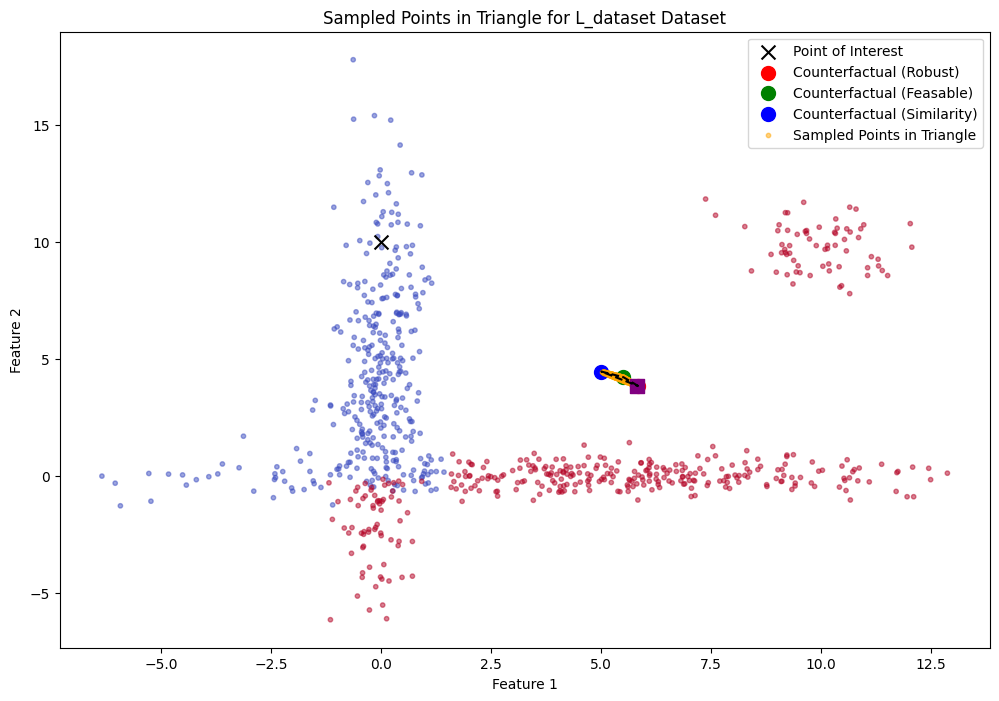

In [16]:
# Plot the sampled points
plt.figure(figsize=(12, 8))
draw_triangle_sampled(cf_robust, cf_feasable, cf_similarity, points, y_labels, point_of_interest, triangle_points, dataset_name)
plt.scatter(
    combined[0],
    combined[1],
    c="purple",
    marker="s",
    s=100,
    label="Combined Point",
)
plt.show()